In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv('dataset/exam_mark_placement.csv')

In [19]:
df.sample(5)

,cgpa,placement_exam_marks,placed
717,6.49,21,0
320,7.18,51,1
555,6.46,32,0
975,8.43,25,1
245,6.78,62,0


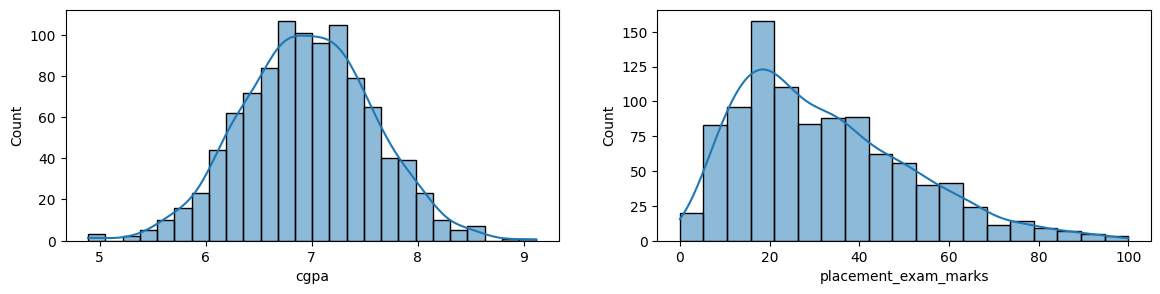

In [22]:
plt.figure(figsize=(14,3))
plt.subplot(1,2,1)
sns.histplot(df.cgpa, kde=True)

plt.subplot(1,2,2)
sns.histplot(df.placement_exam_marks,kde=True)

plt.show()

In [23]:
#cgpa is normally distributed but not placement_exam_marks

In [24]:
np.round(df.describe(),2)

,cgpa,placement_exam_marks,placed
count,1000.00,1000.00,1000.00
mean,6.96,32.22,0.49
std,0.62,19.13,0.50
min,4.89,0.00,0.00
25%,6.55,17.00,0.00
50%,6.96,28.00,0.00
75%,7.37,44.00,1.00
max,9.12,100.00,1.00


In [25]:
upper_limit = df.cgpa.mean() + 3* df.cgpa.std()
lower_limit = df.cgpa.mean() - 3* df.cgpa.std()
print('Upper Limit:',upper_limit)
print('Lower Limit:',lower_limit)

Upper Limit: 8.808933625397168
Lower Limit: 5.113546374602832


In [29]:
#finding outliers
df[(df.cgpa > upper_limit) | (df.cgpa < lower_limit)]

,cgpa,placement_exam_marks,placed
485,4.92,44,1
995,8.87,44,1
996,9.12,65,1
997,4.89,34,0
999,4.90,10,1


### Trimming

In [32]:
new_df = df[(df.cgpa < upper_limit) & (df.cgpa > lower_limit)]
new_df.sample()

,cgpa,placement_exam_marks,placed
227,7.03,19,0


In [33]:
# approach 2
# make different cgpa column
df['cgpa_zscore']=(df['cgpa'] - df['cgpa'].mean())/df['cgpa'].std()

In [36]:
df.sample(5)

,cgpa,placement_exam_marks,placed,cgpa_zscore
877,6.32,9,0,-1.041147
692,6.95,43,0,-0.018250
133,7.65,64,1,1.118302
632,6.37,13,0,-0.959964
598,7.59,27,1,1.020884


In [37]:
# -3 to 3 -> other outliers
new_df = df[(df.cgpa_zscore > -3) & (df.cgpa_zscore < 3) ]
new_df.sample() # outliers removed

,cgpa,placement_exam_marks,placed,cgpa_zscore
677,6.75,24,0,-0.342979


## Capping

In [38]:
upper_limit = df.cgpa.mean() + 3* df.cgpa.std()
lower_limit = df.cgpa.mean() - 3* df.cgpa.std()
print('Upper Limit:',upper_limit)
print('Lower Limit:',lower_limit)

Upper Limit: 8.808933625397168
Lower Limit: 5.113546374602832


In [40]:
df['cgpa'] = np.where(
    df['cgpa']> upper_limit,
    upper_limit,
    np.where(
        df['cgpa']< lower_limit,
        lower_limit, 
        df['cgpa']
    )
    
)

In [42]:
df.shape

(1000, 4)

In [43]:
df.cgpa.describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64